In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import random

In [8]:
event_types = ["Workshop", "Seminar", "Competition", "Hackathon", "Meeting"]
departments = ["CSE", "ECE", "EE", "Mechanical", "Civil", "IT"]
speakers = ["Internal", "External"]

rows = []

In [9]:
for i in range(1, 31):
    registrations = random.randint(80, 220)
    attendance = random.randint(60, registrations)

    rows.append([
        f"E{i:03}",
        f"IEEE Event {i}",
        random.choice(event_types),
        f"2026-{(i%12)+1:02}-15",
        random.randint(1, 6),
        registrations,
        attendance,
        random.randint(5, 40),
        attendance - random.randint(5, 25),
        round(random.uniform(3.8, 5.0), 1),
        random.choice(departments),
        random.choice(speakers),
        random.randint(3000, 35000),
        attendance
    ])

In [10]:
df = pd.DataFrame(rows, columns=[
    "Event ID",
    "Event Name",
    "Event Type",
    "Event Date",
    "Duration Hours",
    "Registrations",
    "Attendance",
    "New Members Joined",
    "Returning Members",
    "Feedback Score",
    "Department",
    "Speaker Type",
    "Budget",
    "Certificates Issued"
])

df.head()

,Event ID,Event Name,Event Type,Event Date,Duration Hours,Registrations,Attendance,New Members Joined,Returning Members,Feedback Score,Department,Speaker Type,Budget,Certificates Issued
0,E001,IEEE Event 1,Competition,2026-02-15,3,107,89,22,80,4.9,CSE,Internal,21876,89
1,E002,IEEE Event 2,Meeting,2026-03-15,1,114,88,13,79,4.3,EE,Internal,34109,88
2,E003,IEEE Event 3,Hackathon,2026-04-15,3,219,120,18,112,5.0,Civil,Internal,16926,120
3,E004,IEEE Event 4,Meeting,2026-05-15,2,147,74,19,53,4.8,CSE,External,15345,74
4,E005,IEEE Event 5,Hackathon,2026-06-15,1,141,134,31,125,4.5,Civil,External,4376,134


In [11]:
df.shape

(30, 14)

In [12]:
df.to_csv("event_data.csv", index=False)

In [13]:
import os

os.path.exists("event_data.csv")

True

In [14]:
from google.colab import files

files.download("event_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
df.head()

,Event ID,Event Name,Event Type,Event Date,Duration Hours,Registrations,Attendance,New Members Joined,Returning Members,Feedback Score,Department,Speaker Type,Budget,Certificates Issued
0,E001,IEEE Event 1,Competition,2026-02-15,3,107,89,22,80,4.9,CSE,Internal,21876,89
1,E002,IEEE Event 2,Meeting,2026-03-15,1,114,88,13,79,4.3,EE,Internal,34109,88
2,E003,IEEE Event 3,Hackathon,2026-04-15,3,219,120,18,112,5.0,Civil,Internal,16926,120
3,E004,IEEE Event 4,Meeting,2026-05-15,2,147,74,19,53,4.8,CSE,External,15345,74
4,E005,IEEE Event 5,Hackathon,2026-06-15,1,141,134,31,125,4.5,Civil,External,4376,134


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Event ID             30 non-null     object 
 1   Event Name           30 non-null     object 
 2   Event Type           30 non-null     object 
 3   Event Date           30 non-null     object 
 4   Duration Hours       30 non-null     int64  
 5   Registrations        30 non-null     int64  
 6   Attendance           30 non-null     int64  
 7   New Members Joined   30 non-null     int64  
 8   Returning Members    30 non-null     int64  
 9   Feedback Score       30 non-null     float64
 10  Department           30 non-null     object 
 11  Speaker Type         30 non-null     object 
 12  Budget               30 non-null     int64  
 13  Certificates Issued  30 non-null     int64  
dtypes: float64(1), int64(7), object(6)
memory usage: 3.4+ KB


In [17]:
df.describe()

,Duration Hours,Registrations,Attendance,New Members Joined,Returning Members,Feedback Score,Budget,Certificates Issued
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,3.233333,150.766667,104.033333,20.033333,90.833333,4.463333,19411.300000,104.033333
std,1.735697,34.775817,30.513404,9.771469,30.696606,0.349860,10618.485427,30.513404
min,1.000000,94.000000,63.000000,6.000000,46.000000,3.900000,4261.000000,63.000000
25%,2.000000,121.250000,78.750000,11.500000,70.250000,4.200000,9346.750000,78.750000
50%,3.000000,148.000000,98.500000,18.500000,85.500000,4.500000,21122.500000,98.500000
75%,5.000000,176.500000,124.500000,29.500000,113.500000,4.800000,28905.750000,124.500000
max,6.000000,219.000000,180.000000,39.000000,160.000000,5.000000,34355.000000,180.000000


In [18]:
print("Attendance <= Registrations:",
      (df["Attendance"] <= df["Registrations"]).all())

print("Feedback Score between 1 and 5:",
      ((df["Feedback Score"] >= 1) &
       (df["Feedback Score"] <= 5)).all())

print("Budget is Positive:",
      (df["Budget"] > 0).all())

print("\nMissing Values:")
print(df.isnull().sum())

Attendance <= Registrations: True
Feedback Score between 1 and 5: True
Budget is Positive: True

Missing Values:
Event ID               0
Event Name             0
Event Type             0
Event Date             0
Duration Hours         0
Registrations          0
Attendance             0
New Members Joined     0
Returning Members      0
Feedback Score         0
Department             0
Speaker Type           0
Budget                 0
Certificates Issued    0
dtype: int64


In [19]:
attendance_summary = df["Attendance"].describe()

print(attendance_summary)

count     30.000000
mean     104.033333
std       30.513404
min       63.000000
25%       78.750000
50%       98.500000
75%      124.500000
max      180.000000
Name: Attendance, dtype: float64


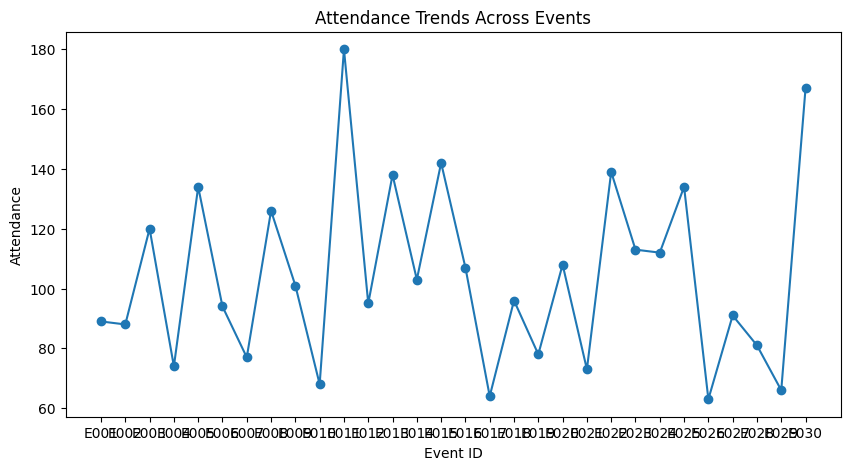

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    df["Event ID"],
    df["Attendance"],
    marker="o"
)

plt.title("Attendance Trends Across Events")
plt.xlabel("Event ID")
plt.ylabel("Attendance")

plt.savefig("attendance.png")

plt.show()

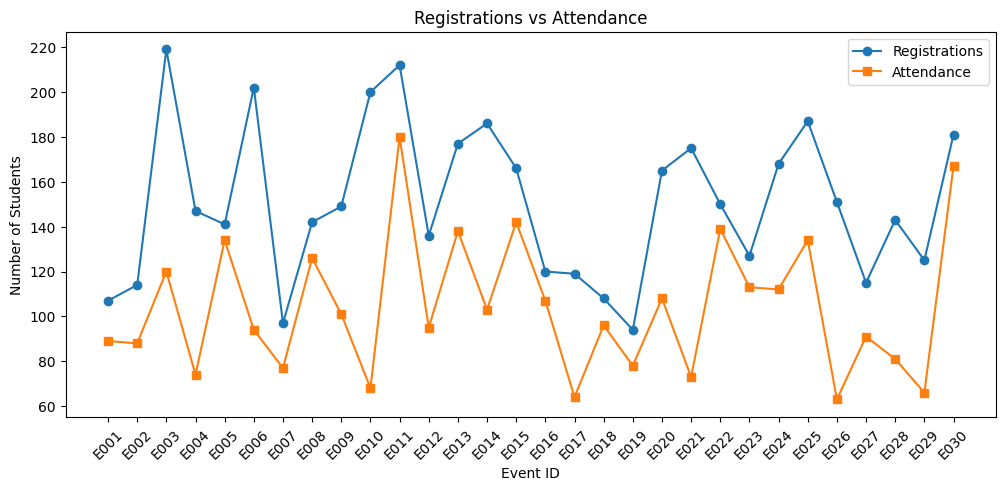

In [21]:
plt.figure(figsize=(12,5))

plt.plot(df["Event ID"], df["Registrations"], marker="o", label="Registrations")
plt.plot(df["Event ID"], df["Attendance"], marker="s", label="Attendance")

plt.title("Registrations vs Attendance")
plt.xlabel("Event ID")
plt.ylabel("Number of Students")

plt.legend()

plt.xticks(rotation=45)

plt.savefig("registration_vs_attendance.png")

plt.show()

In [22]:
popularity = df.groupby("Event Type")["Attendance"].mean()

print(popularity)

Event Type
Competition    106.500000
Hackathon      119.600000
Meeting        104.500000
Seminar         94.285714
Workshop        97.000000
Name: Attendance, dtype: float64


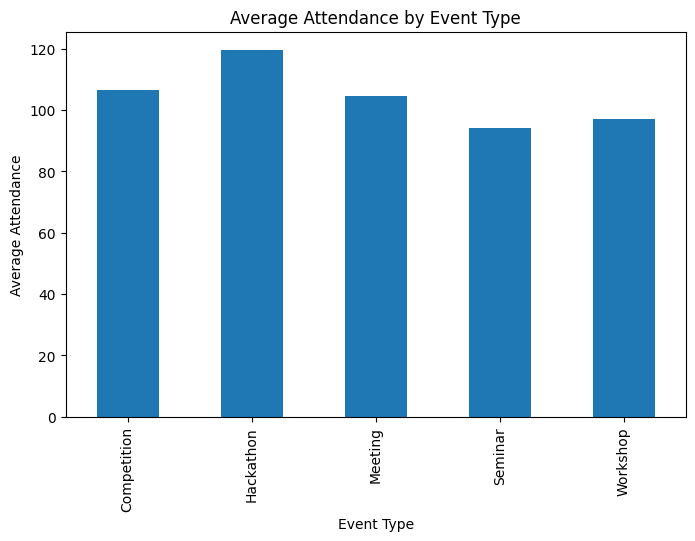

In [23]:
popularity.plot(kind="bar", figsize=(8,5))

plt.title("Average Attendance by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Attendance")

plt.savefig("popularity.png")

plt.show()

In [24]:
retention = df[["New Members Joined", "Returning Members"]].sum()

print(retention)

New Members Joined     601
Returning Members     2725
dtype: int64


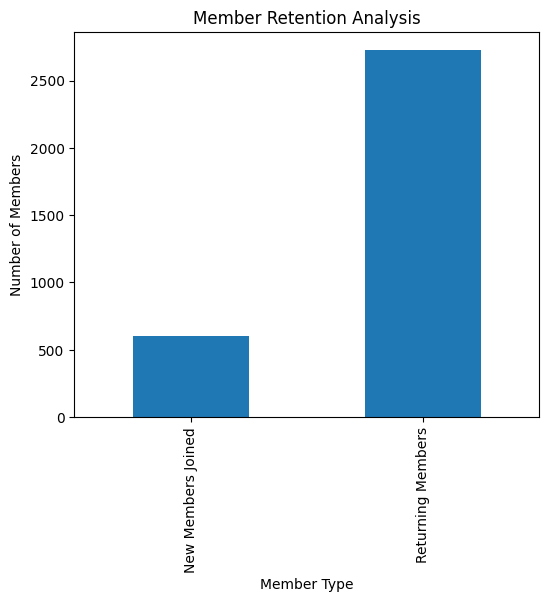

In [25]:
retention.plot(kind="bar", figsize=(6,5))

plt.title("Member Retention Analysis")
plt.xlabel("Member Type")
plt.ylabel("Number of Members")

plt.savefig("retention.png")

plt.show()

In [26]:
budget = df.groupby("Event Type")["Budget"].mean()

print(budget)

Event Type
Competition    17614.500000
Hackathon      13476.800000
Meeting        22740.625000
Seminar        14885.571429
Workshop       30786.000000
Name: Budget, dtype: float64


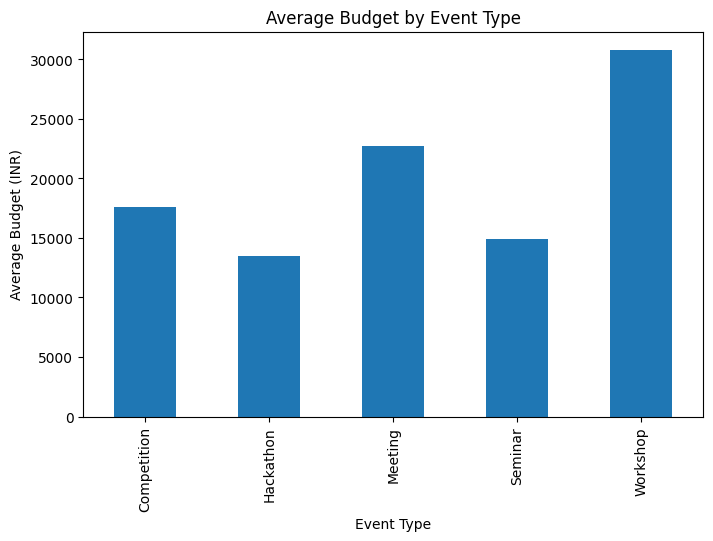

In [27]:
budget.plot(kind="bar", figsize=(8,5))

plt.title("Average Budget by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Budget (INR)")

plt.savefig("budget.png")

plt.show()

In [28]:
print("Standard Deviation of Registrations:")
print(df["Registrations"].std())

print("\nStandard Deviation of Attendance:")
print(df["Attendance"].std())

print("\nStandard Deviation of Budget:")
print(df["Budget"].std())

Standard Deviation of Registrations:
34.77581733423915

Standard Deviation of Attendance:
30.51340387586993

Standard Deviation of Budget:
10618.485427261534


In [29]:
print("========== IEEE STUDENT BRANCH DASHBOARD ==========")

print("Total Events:", len(df))

print("Total Registrations:", df["Registrations"].sum())

print("Total Attendance:", df["Attendance"].sum())

print("Average Attendance:",
      round(df["Attendance"].mean(), 2))

print("Average Feedback Score:",
      round(df["Feedback Score"].mean(), 2))

print("Total Budget (INR):",
      df["Budget"].sum())

highest = df.loc[df["Attendance"].idxmax()]

print("\nHighest Attendance Event:")
print("Event Name:", highest["Event Name"])
print("Attendance:", highest["Attendance"])
print("Event Type:", highest["Event Type"])

========== IEEE STUDENT BRANCH DASHBOARD ==========
Total Events: 30
Total Registrations: 4523
Total Attendance: 3121
Average Attendance: 104.03
Average Feedback Score: 4.46
Total Budget (INR): 582339

Highest Attendance Event:
Event Name: IEEE Event 11
Attendance: 180
Event Type: Hackathon


In [1]:
from google.colab import files

files.download("attendance.png")
files.download("registration_vs_attendance.png")
files.download("popularity.png")
files.download("retention.png")
files.download("budget.png")

FileNotFoundError: Cannot find file: attendance.png